# Spatial Filters in OpenCV

This notebook explains **what image filters do**, how **kernels (convolution masks)** work, and when to use each OpenCV blur/smoothing function.

**Image sources:** `skimage.data.camera`, `skimage.data.astronaut` (built-in test images).

---

## 1. What is filtering?

A **filter** replaces each pixel with a function of its neighborhood. In the **linear** case we use **convolution**:

$$g(x,y) = \sum_{u,v} f(x-u,\; y-v)\; h(u,v)$$

| Symbol | Meaning |
|--------|---------|
| $f$ | input image |
| $h$ | **kernel** (filter mask) — small matrix of weights |
| $g$ | filtered output |

The kernel defines **what the filter does**:
- **Uniform positive weights** → averaging → **blur / smooth**
- **Center positive, neighbors negative** → **sharpen** (highlights edges)
- **Non-linear** (median, bilateral) → output is **not** a weighted sum; better for specific noise

### 1.1 Kernel size

OpenCV functions take `ksize` (odd integer, e.g. 3, 5, 7). Larger kernel → larger neighborhood → **stronger** smoothing but **more blur** and slower computation.

### 1.2 Linear vs non-linear

| Type | Examples | Uses weighted sum? |
|------|----------|-------------------|
| **Linear** | Box, Gaussian, `filter2D` | Yes |
| **Non-linear** | Median, bilateral | No |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from urllib.request import urlretrieve
import skimage.data as skid

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

NOTEBOOK_DIR = Path.cwd()
IMAGES_CACHE = NOTEBOOK_DIR.parent / "Images"
IMAGES_CACHE.mkdir(exist_ok=True)

ECE533_URLS = {
    "peppers": "https://homepages.cae.wisc.edu/~ece533/images/peppers.png",
    "boat": "https://homepages.cae.wisc.edu/~ece533/images/boat.png",
    "baboon": "https://homepages.cae.wisc.edu/~ece533/images/baboon.png",
}

SKIMAGE_FALLBACK = {
    "peppers": skid.astronaut,
    "boat": skid.camera,
    "baboon": skid.chelsea,
}


def load_sample_image(name):
    """Load from skimage.data or download Wisconsin ECE533 image (cached locally)."""
    skimg_map = {
        "camera": skid.camera,
        "coins": skid.coins,
        "astronaut": skid.astronaut,
        "coffee": skid.coffee,
        "chelsea": skid.chelsea,
        "page": skid.page,
    }
    if name in skimg_map:
        img = skimg_map[name]()
        if img.ndim == 2:
            return img.astype(np.uint8)
        return cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    cache_path = IMAGES_CACHE / f"{name}.png"
    if cache_path.exists():
        img = cv2.imread(str(cache_path), cv2.IMREAD_UNCHANGED)
        if img is not None:
            return img

    url = ECE533_URLS.get(name)
    if url:
        try:
            print(f"Downloading {name} from ECE533 ...")
            urlretrieve(url, cache_path)
            img = cv2.imread(str(cache_path), cv2.IMREAD_UNCHANGED)
            if img is not None:
                return img
        except Exception as exc:
            print(f"Download failed ({exc}); using skimage fallback.")

    fallback = SKIMAGE_FALLBACK.get(name, skid.camera)
    img = fallback()
    if img.ndim == 2:
        return img.astype(np.uint8)
    return cv2.cvtColor(img, cv2.COLOR_RGB2BGR)


def to_rgb(bgr):
    if bgr.ndim == 2:
        return bgr
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def show_gray(ax, img, title=""):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")


def show_rgb(ax, img_bgr, title=""):
    ax.imshow(to_rgb(img_bgr))
    ax.set_title(title)
    ax.axis("off")


def side_by_side(images, titles, rgb_flags=None, cols=5):
    """Plot a row/grid of images. images: list of arrays; rgb_flags: True for BGR color."""
    n = len(images)
    cols = min(cols, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.2 * rows))
    axes = np.atleast_1d(axes).ravel()
    for i, (img, title) in enumerate(zip(images, titles)):
        is_rgb = rgb_flags[i] if rgb_flags else (img.ndim == 3)
        if is_rgb:
            show_rgb(axes[i], img, title)
        else:
            show_gray(axes[i], img, title)
    for j in range(n, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()


def add_salt_pepper(gray, amount=0.05):
    """Inject salt-and-pepper noise into a uint8 grayscale image."""
    out = gray.copy()
    n = int(amount * gray.size)
    rng = np.random.default_rng(42)
    coords = (rng.integers(0, gray.shape[0], n), rng.integers(0, gray.shape[1], n))
    out[coords] = 255
    coords = (rng.integers(0, gray.shape[0], n), rng.integers(0, gray.shape[1], n))
    out[coords] = 0
    return out


## 2. Box filter (`cv2.blur`)

**What it does:** replaces each pixel with the **mean** of its neighborhood.

**Kernel:** all entries equal $1 / (k \times k)$.

| Effect | Detail |
|--------|--------|
| Smooths | Reduces high-frequency detail and noise |
| Blurs edges | Averages across object boundaries |
| Fast | Simple sum / count |

Border types: https://vovkos.github.io/doxyrest-showcase/opencv/sphinx_rtd_theme/enum_cv_BorderTypes.html

OpenCV: `cv2.blur(src, ksize=(k,k))`


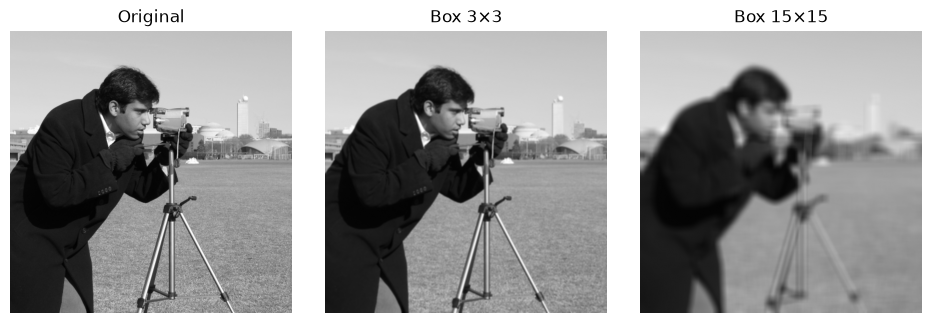

In [2]:
camera = load_sample_image("camera")
box3 = cv2.blur(camera, (3, 3))
box15 = cv2.blur(camera, (15, 15))
side_by_side([camera, box3, box15], ["Original", "Box 3×3", "Box 15×15"])

## 3. Gaussian filter (`cv2.GaussianBlur`)

**What it does:** weighted average using a **Gaussian** (bell-shaped) kernel — center pixels matter more than distant ones.

**Why use it instead of box?** Smoother result, fewer boxy artifacts. Often used as a pre-filter before edge detection.

| Parameter | Role |
|-----------|------|
| `ksize` | kernel width/height (odd) |
| `sigmaX`, `sigmaY` | standard deviation of Gaussian; if 0, computed from `ksize` |

Large $\sigma$ → wider bell → **more blur**.


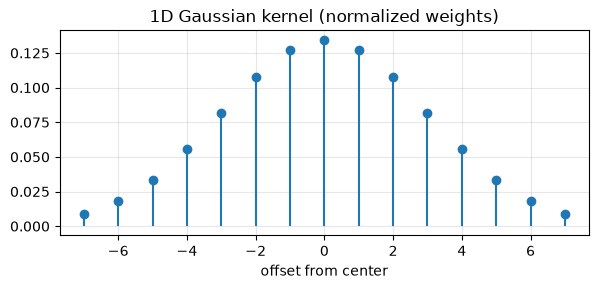

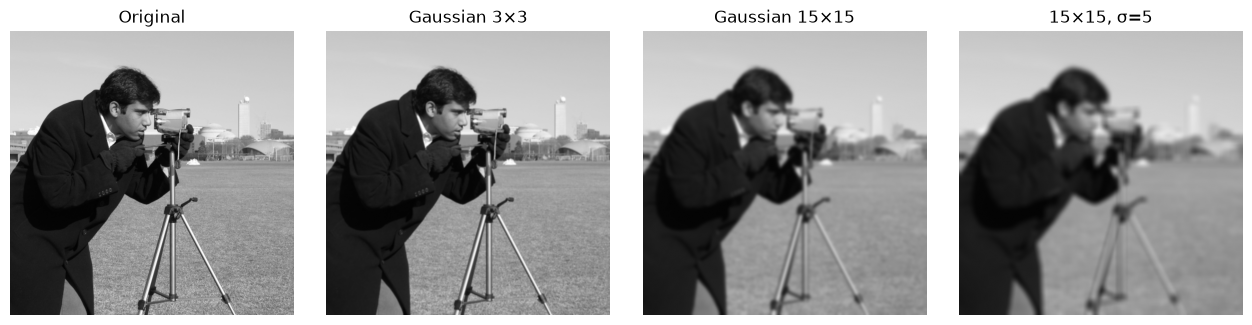

In [3]:
gauss3 = cv2.GaussianBlur(camera, (3, 3), 0)
gauss15 = cv2.GaussianBlur(camera, (15, 15), 0)
gauss_big_sigma = cv2.GaussianBlur(camera, (15, 15), sigmaX=5)

# Visualize a 1D Gaussian kernel shape
k = 15
x = np.arange(k) - k // 2
sigma = 3
g1d = np.exp(-(x ** 2) / (2 * sigma ** 2))
g1d /= g1d.sum()
fig, ax = plt.subplots(figsize=(6, 3))
ax.stem(x, g1d, basefmt=" ")
ax.set_title("1D Gaussian kernel (normalized weights)")
ax.set_xlabel("offset from center")
plt.tight_layout()
plt.show()

side_by_side(
    [camera, gauss3, gauss15, gauss_big_sigma],
    ["Original", "Gaussian 3×3", "Gaussian 15×15", "15×15, σ=5"],
)


## 4. Median filter (`cv2.medianBlur`)

**What it does:** replaces each pixel with the **median** of its neighborhood (not the mean).

| Good for | Bad for |
|----------|---------|
| **Salt-and-pepper** impulse noise | Fine texture (can look patchy) |
| Preserving edges better than mean blur | Large kernels on smooth gradients |

**Non-linear** — one outlier pixel (salt/pepper) does not pull the median far from the true value.


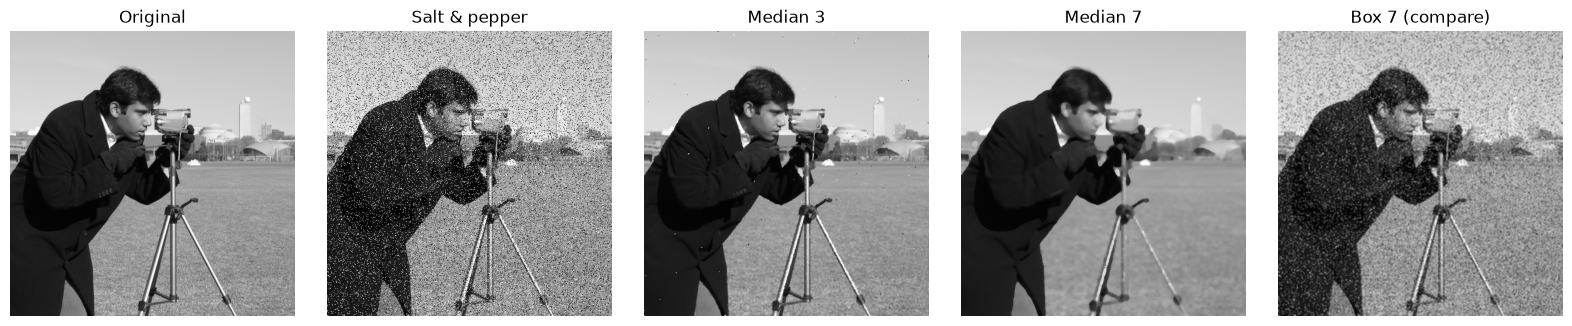

In [4]:
noisy = add_salt_pepper(camera, amount=0.08)
med3 = cv2.medianBlur(noisy, 3)
med7 = cv2.medianBlur(noisy, 7)
box_noisy = cv2.blur(noisy, (3, 3))

side_by_side(
    [camera, noisy, med3, med7, box_noisy],
    ["Original", "Salt & pepper", "Median 3", "Median 7", "Box 7 (compare)"],
)


## 5. Bilateral filter (`cv2.bilateralFilter`)

**What it does:** edge-preserving smoothing. Combines two Gaussians:
1. **Spatial** — nearby pixels (like Gaussian blur)
2. **Range (intensity)** — pixels with **similar intensity** only

| Parameter | Role |
|-----------|------|
| `d` | diameter of pixel neighborhood |
| `sigmaColor` | how much intensity difference is allowed |
| `sigmaSpace` | spatial extent |

**Result:** smooth flat regions, **keep sharp edges** — unlike Gaussian blur.


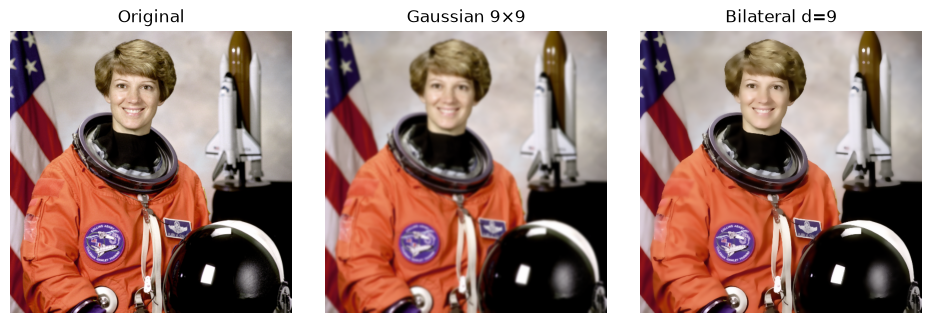

In [5]:
astronaut = load_sample_image("astronaut")
bilat = cv2.bilateralFilter(astronaut, d=9, sigmaColor=75, sigmaSpace=75)
gauss_color = cv2.GaussianBlur(astronaut, (9, 9), 0)

side_by_side(
    [astronaut, gauss_color, bilat],
    ["Original", "Gaussian 9×9", "Bilateral d=9"],
    rgb_flags=[True, True, True],
)


## 6. Custom kernels (`cv2.filter2D`)

**What it does:** convolve the image with **any** kernel you define.

Common examples:

| Kernel | Effect |
|--------|--------|
| Identity | no change |
| Sharpen | center +, neighbors − → boost high frequencies |
| Emboss | directional derivative → 3D relief look |
| Laplacian (3×3) | second derivative → edges |

$$\text{sharpen} = \begin{bmatrix} 0 & -1 & 0 \\ -1 & 5 & -1 \\ 0 & -1 & 0 \end{bmatrix}$$


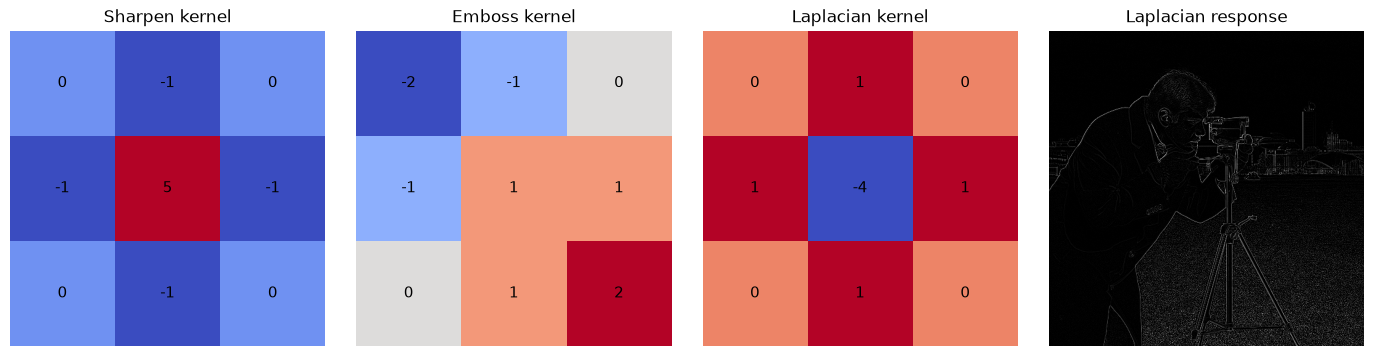

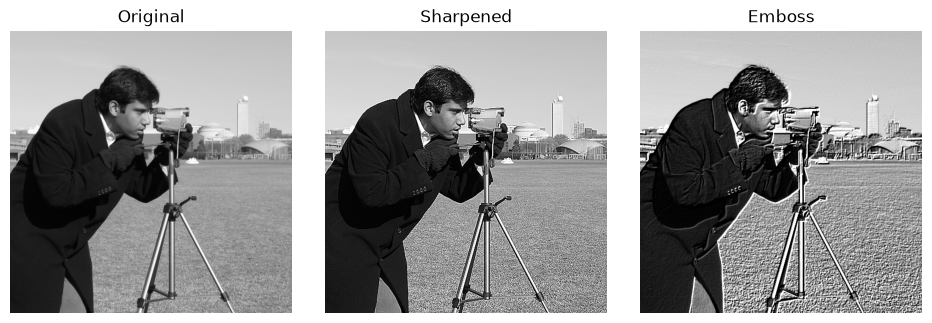

In [6]:
sharpen = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
emboss = np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]], dtype=np.float32)
laplacian_k = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32)

sharp_img = cv2.filter2D(camera, -1, sharpen)
emboss_img = cv2.filter2D(camera, -1, emboss)
lap_img = cv2.filter2D(camera, -1, laplacian_k)
lap_abs = cv2.convertScaleAbs(lap_img)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, k, title in zip(
    axes,
    [sharpen, emboss, laplacian_k, None],
    ["Sharpen kernel", "Emboss kernel", "Laplacian kernel", "Laplacian response"],
):
    if k is not None:
        ax.imshow(k, cmap="coolwarm")
        for (i, j), val in np.ndenumerate(k):
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", color="black", fontsize=11)
    else:
        show_gray(ax, lap_abs, title)
        continue
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

side_by_side([camera, sharp_img, emboss_img], ["Original", "Sharpened", "Emboss"])


## 7. Edge operators — are they filters?

**Yes** — Sobel, Laplacian, and Scharr are **linear spatial filters** (convolution with derivative kernels), just like sharpen/emboss in §6.

| Operator | OpenCV | Role |
|----------|--------|------|
| **Sobel** | `cv2.Sobel` | First derivative; gradient magnitude |
| **Laplacian** | `cv2.Laplacian` or `filter2D` | Second derivative; edge emphasis |
| **Scharr** | `cv2.Scharr` | 3×3 gradient, better rotation symmetry |

**Canny** is covered in `03_edge_detection_contours.ipynb` — it is a multi-step algorithm, not a single kernel.

$$G_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}  G_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}$$

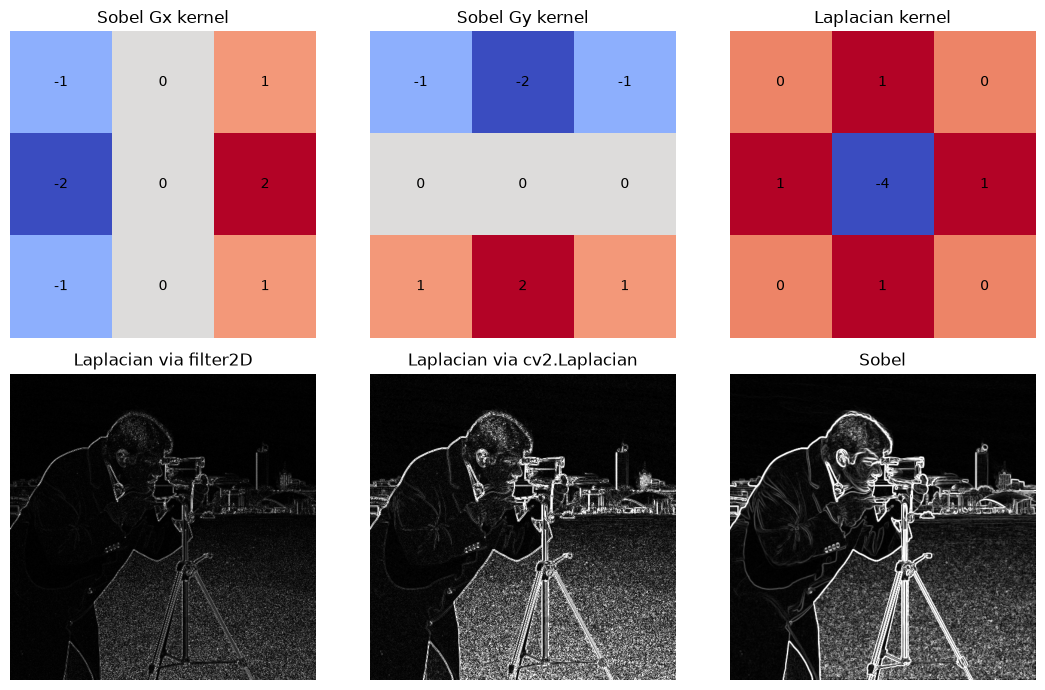

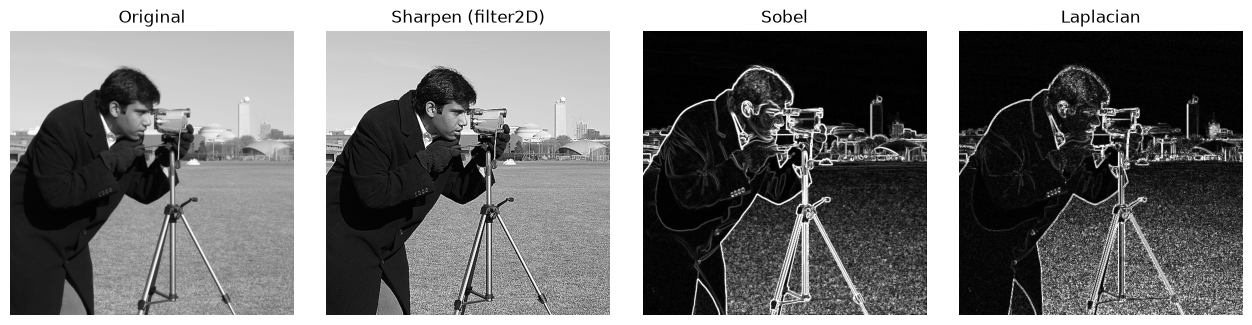

In [7]:
if "laplacian_k" not in globals():
    laplacian_k = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32)
if "sharp_img" not in globals():
    sharpen = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
    sharp_img = cv2.filter2D(camera, -1, sharpen)

# Laplacian: custom filter2D vs cv2.Laplacian
lap_custom = cv2.filter2D(camera, cv2.CV_64F, laplacian_k)
lap_cv = cv2.Laplacian(camera, cv2.CV_64F, ksize=3)
lap_custom_u8 = cv2.convertScaleAbs(lap_custom)
lap_cv_u8 = cv2.convertScaleAbs(lap_cv)

# Sobel gradients and magnitude (on the image, not on kernels)
gx = cv2.Sobel(camera, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(camera, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = cv2.convertScaleAbs(cv2.magnitude(gx, gy))

# Kernel weights for visualization
sobel_x_k = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
sobel_y_k = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
kernel_row = [
    (sobel_x_k, "Sobel Gx kernel"),
    (sobel_y_k, "Sobel Gy kernel"),
    (laplacian_k, "Laplacian kernel"),
]
for ax, (k, title) in zip(axes[0], kernel_row):
    ax.imshow(k, cmap="coolwarm")
    for (i, j), val in np.ndenumerate(k):
        ax.text(j, i, f"{val:.0f}", ha="center", va="center", color="black", fontsize=10)
    ax.set_title(title)
    ax.axis("off")

show_gray(axes[1, 0], lap_custom_u8, "Laplacian via filter2D")
show_gray(axes[1, 1], lap_cv_u8, "Laplacian via cv2.Laplacian")
show_gray(axes[1, 2], sobel_mag, "Sobel")
plt.tight_layout()
plt.show()

side_by_side(
    [camera, sharp_img, sobel_mag, lap_cv_u8],
    ["Original", "Sharpen (filter2D)", "Sobel", "Laplacian"],
)

## 8. Summary — which filter when?

| Filter / operator | Type | Main effect | Best for |
|-------------------|------|-------------|----------|
| **Box blur** | Linear | Mean smoothing | Quick noise reduction |
| **Gaussian** | Linear | Weighted smooth | General blur, edge-detection pre-filter |
| **Median** | Non-linear | Rank filter | Salt-and-pepper noise |
| **Bilateral** | Non-linear | Edge-preserving smooth | Denoise while keeping edges |
| **filter2D** | Linear | Custom convolution | Sharpen, emboss, any kernel |
| **Sobel / Laplacian** | Linear | Derivative kernels | Gradients, edge emphasis |

**Kernel size rule of thumb:** start small (3×3), increase only if you need a stronger effect.

**Edge vs smooth:** blurring kernels average neighbors; derivative kernels (Sobel, Laplacian) highlight *change* between neighbors. For Canny and contours, see `03_edge_detection_contours.ipynb`.
